In [ ]:
import pandas as pd
df = pd.read_csv('API_SP.POP.TOTL_DS2_en_csv_v2_61.csv', skiprows=4)

# Remove unwanted columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Show first 5 rows
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


In [ ]:
df_clean = df[['Country Name', 'Country Code', '2024']].dropna()

df_clean = df_clean.rename(columns={
    'Country Name': 'Country',
    'Country Code': 'Code',
    '2024': 'Population'
})

In [ ]:
real_countries = [
    'IND','CHN','USA','IDN','PAK','NGA','BRA','BGD','RUS','MEX',
    'JPN','ETH','PHL','EGY','VNM','COD','TUR','IRN','DEU','THA'
]

df_clean = df_clean[df_clean['Code'].isin(real_countries)]


In [ ]:
total_population = df_clean['Population'].sum()

df_clean['World Population %'] = (df_clean['Population'] / total_population) * 100

In [ ]:
top10 = df_clean.sort_values(by='Population', ascending=False).head(10).reset_index(drop=True)

print("\nTop 10 Most Populated Countries (2024)\n")

display(top10.style.format({
    'Population': '{:,.0f}',
    'World Population %': '{:.2f}%'
}))


Top 10 Most Populated Countries (2024)



,Country,Code,Population,World Population %
0,India,IND,"1,450,935,791",25.64%
1,China,CHN,"1,408,975,000",24.90%
2,United States,USA,"340,110,988",6.01%
3,Indonesia,IDN,"283,487,931",5.01%
4,Pakistan,PAK,"251,269,164",4.44%
5,Nigeria,NGA,"232,679,478",4.11%
6,Brazil,BRA,"211,998,573",3.75%
7,Bangladesh,BGD,"173,562,364",3.07%
8,Russian Federation,RUS,"143,533,851",2.54%
9,Ethiopia,ETH,"132,059,767",2.33%


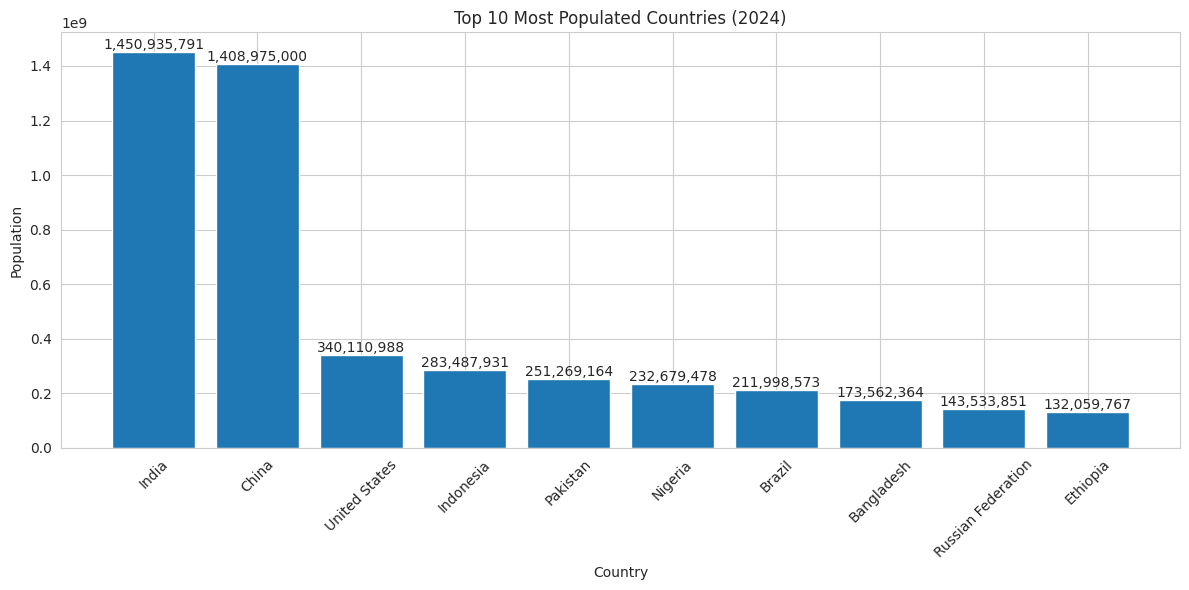

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bars = plt.bar(top10['Country'], top10['Population'])

plt.title('Top 10 Most Populated Countries (2024)')
plt.xlabel('Country')
plt.ylabel('Population')

plt.xticks(rotation=45)

# Full value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{int(yval):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

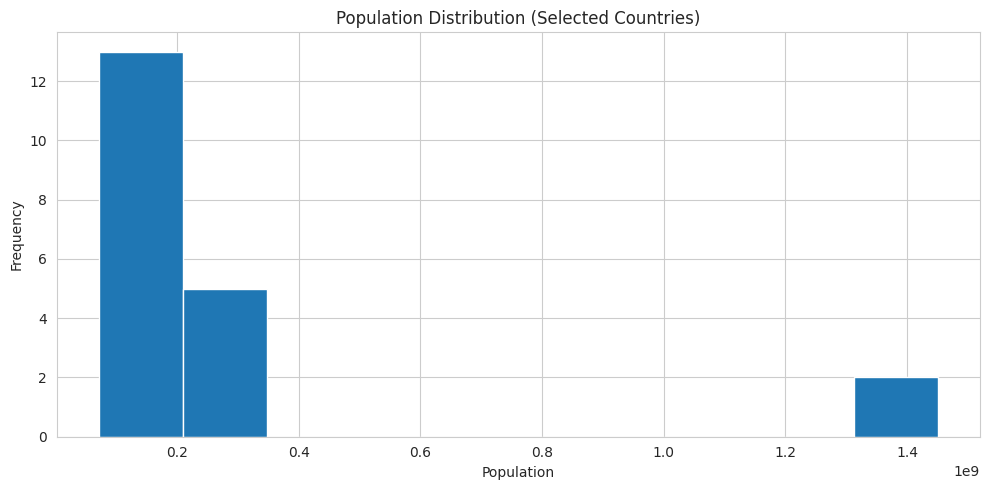

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df_clean['Population'], bins=10)

plt.title('Population Distribution (Selected Countries)')
plt.xlabel('Population')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()